In [2]:
import os
import boto3
import json
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import shape
import matplotlib.pyplot as plt
from botocore.exceptions import ClientError
import mlflow
import mlflow.pytorch
import torch
import xarray as xr
from snowML.datapipe.utils import data_utils as du
from snowML.datapipe.utils import get_geos as gg
from sklearn.metrics import mean_squared_error
import tempfile

import importlib
import train_eval_pipeline_feature_ranking as tefr
importlib.reload(tefr)
from train_eval_pipeline_feature_ranking import train_model, test_model, compute_metrics

/home/sagemaker-user/.conda/envs/myenv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/sagemaker-user/.conda/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =============================================================================
# CONFIG: All parameters in one place (features, hyperparameters, dates, MLflow)
# =============================================================================

# --- S3 / Data source ---
BUCKET_NAME = "snowml-shape"
MODEL_READY_BUCKET = "snowml-model-ready-stgnn"
AWS_REGION = "us-west-2"

# --- Region / HUCs ---
HUC_LEVEL = "12"
HUC8_IDS = [
    17020009, 17020011, 17110005, 17110006, 17110009,
    17010304, 17010302, 17060207, 17060208, 17030001, 17030002,
    17110008, 17030003, 17020010, 17110007,
]
EXCLUDED_HUCS_CA = [
    "171100050101", "171100050102", "171100050201", "171100050202", "171100050203",
    "171100050301", "171100050302", "171100050303", "171100050304", "171100050305",
    "171100050306", "171100050401",
]

WEIRD_HUCS = ['171100060305', '171100060401', '171100060404', '171100060405']

EXCLUDED_HUCS = EXCLUDED_HUCS_CA + WEIRD_HUCS

# Adjacency matrix features
ADJ_SIGMA_CUTOFF = 3
ADJ_ALPHA = 0.7

# --- Base model (for reference) ---
BASE_LAG = "mean_swe_lag_7"
ADDITIONAL_LAG = "mean_swe_lag_30"
BASE_DYNAMIC = ["mean_pr", "mean_tair", BASE_LAG]
BASE_STATIC_MR = ["Mean Elevation"]
BASE_STATIC_GEOM = []
BASE_STATIC_DERIVED = []

# --- Extra features (for reference) ---
EXTRA_DYNAMIC = ["snow_cover", "mean_hum", "mean_srad", "mean_vs", ADDITIONAL_LAG]
EXTRA_STATIC_MR = ["slope", "Predominant Snow", "Mean Forest Cover"]
EXTRA_STATIC_DERIVED = ["mean_pr_djf", "mean_tair_djf"] # Derived static features computed from time-series over the training window
EXTRA_STATIC_GEOM = ["area"]

# --- Changing BASE LAG ---
lag_base = "_".join(BASE_LAG.split("_")[-2:])
lag_extra = "_".join(ADDITIONAL_LAG.split("_")[-2:])
FEATURE_NAME = f"{lag_extra}-{lag_base}"
EXTRA_DYNAMIC_LAG = [FEATURE_NAME]

# --- Static features in zarr ---
STATIC_IN_ZARR = ["Predominant Snow", "Mean Elevation"]

# --- Load once: all dynamic and static features (for slicing in loop) ---
ALL_DYNAMIC = BASE_DYNAMIC + EXTRA_DYNAMIC
ALL_STATIC_GEOM = BASE_STATIC_GEOM + EXTRA_STATIC_GEOM
ALL_STATIC_MR = BASE_STATIC_MR + EXTRA_STATIC_MR
ALL_STATIC_DERIVED = BASE_STATIC_DERIVED + EXTRA_STATIC_DERIVED

# --- Train / test split ---
TRAIN_SIZE_FRACTION = 0.67 # 67% train period, 33% test period

# --- Training hyperparameters (passed to train_model) ---
NUM_EPOCHS = 20
BATCH_SIZE = 32
SEQ_LEN = 30
VAL_SPLIT = 0.2
EARLY_STOPPING = True
PATIENCE = 5
REL_THRESHOLD = 0.03
NUM_REPS = 3

# --- MLflow ---
MLFLOW_TRACKING_URI = "arn:aws:sagemaker:us-west-2:677276086662:mlflow-tracking-server/wi26-snowml-mlflow"
EXPERIMENT_NAME = f"stgnn_swe_feature_selection_base_{lag_base}_v2"

In [4]:
s3_client = boto3.client("s3", region_name=AWS_REGION)

# Load Geojson Data of HUC12s in the PNW region from `snowml-shape` bucket

In [5]:
def get_geo_jsons(huc_ids, huc_level, bucket_nm="snowml-shape"):
    gdf = []
    for huc_id in huc_ids:
        temp = None
        f_out = f"Huc{huc_level}_in_{huc_id}.geojson"
        if du.isin_s3(bucket_nm, f_out):
            print(f"Getting geos from s3 bucket for {huc_id}")
            temp = du.s3_to_gdf(bucket_nm, f_out)
        else:
            try:
                print(f"Getting geos from google earth for {huc_id}")
                temp = gg.get_geos(huc_id, huc_level, s3_save=True, bucket_nm=bucket_nm)
            except Exception as e:
                # log the error and continue; store None for this huc_id
                print(f"Error getting geos for {huc_id}: {e}")
        if temp is not None:
            temp['huc8'] = huc_id  # Add huc8 df column for all rows in this GeoDataFrame
            gdf.append(temp)
            print(f"Found {len(temp)} HUC {huc_level}s in {huc_id}")
    return gpd.GeoDataFrame(pd.concat(gdf, ignore_index=True))

In [6]:
gdf = get_geo_jsons(HUC8_IDS, HUC_LEVEL, BUCKET_NAME)
print(len(gdf))

Getting geos from s3 bucket for 17020009
Found 29 HUC 12s in 17020009
Getting geos from s3 bucket for 17020011
Found 43 HUC 12s in 17020011
Getting geos from s3 bucket for 17110005
Found 57 HUC 12s in 17110005
Getting geos from s3 bucket for 17110006
Found 21 HUC 12s in 17110006
Getting geos from s3 bucket for 17110009
Found 21 HUC 12s in 17110009
Getting geos from s3 bucket for 17010304
Found 52 HUC 12s in 17010304
Getting geos from s3 bucket for 17010302
Found 8 HUC 12s in 17010302
Getting geos from s3 bucket for 17060207
Found 51 HUC 12s in 17060207
Getting geos from s3 bucket for 17060208
Found 44 HUC 12s in 17060208
Getting geos from s3 bucket for 17030001
Found 52 HUC 12s in 17030001
Getting geos from s3 bucket for 17030002
Found 29 HUC 12s in 17030002
Getting geos from s3 bucket for 17110008
Found 20 HUC 12s in 17110008
Getting geos from s3 bucket for 17030003
Found 72 HUC 12s in 17030003
Getting geos from s3 bucket for 17020010
Found 41 HUC 12s in 17020010
Getting geos from s3 

In [7]:
huc12_ids = gdf['huc_id']

In [8]:
huc12_ids = [huc for huc in huc12_ids if huc not in EXCLUDED_HUCS]
len(huc12_ids)

535

In [9]:
gdf = gdf[~gdf['huc_id'].isin(EXCLUDED_HUCS)]
print(len(gdf))
huc12_ids = gdf["huc_id"]

535


# Load timeseries and static data from `snowml-model-ready` bucket

In [10]:
model_ready_files = [f'model_ready_huc{huc_id}.csv' for huc_id in huc12_ids]
missing_files = [f for f in model_ready_files if not du.isin_s3(MODEL_READY_BUCKET, f)]
print(f"Number of missing files: {len(missing_files)}")
print("Missing files:", missing_files)

Number of missing files: 0
Missing files: []


In [11]:
def get_model_ready_data(huc_ids, bucket_nm=MODEL_READY_BUCKET):
    huc_dfs = []
    for huc_id in huc_ids:
        f_out = f"model_ready_huc{huc_id}.csv"
        df = du.s3_to_df(f_out, bucket_nm)
        df['huc_id'] = huc_id
        df['day'] = pd.to_datetime(df["day"])
        huc_dfs.append(df)
    return pd.concat(huc_dfs, ignore_index=True)


huc_dfs = get_model_ready_data(huc12_ids)
print(huc_dfs.head())

         day  mean_pr  mean_tair  mean_vs  mean_srad  mean_hum  mean_swe  \
0 1983-10-01     0.00     2.8250    3.100    114.875  0.474750  0.000333   
1 1983-10-02     0.00     3.0500    4.250    159.050  0.633750  0.000000   
2 1983-10-03     1.55     3.8750    5.450    122.525  0.746500  0.000000   
3 1983-10-04     0.50     2.3125    4.350    179.775  0.728875  0.000000   
4 1983-10-05     0.00     2.2125    3.175    148.275  0.643000  0.000000   

   Mean Elevation Predominant Snow  Mean Forest Cover  mean_swe_lag_7  \
0     1758.266724         Maritime          38.389219             NaN   
1     1758.266724         Maritime          38.389219             NaN   
2     1758.266724         Maritime          38.389219             NaN   
3     1758.266724         Maritime          38.389219             NaN   
4     1758.266724         Maritime          38.389219             NaN   

   mean_swe_lag_30  mean_swe_lag_60  snow_cover  era5_swe      slope  \
0              NaN              

In [12]:
print(len(huc_dfs))
huc_dfs.columns

7620540


Index(['day', 'mean_pr', 'mean_tair', 'mean_vs', 'mean_srad', 'mean_hum',
       'mean_swe', 'Mean Elevation', 'Predominant Snow', 'Mean Forest Cover',
       'mean_swe_lag_7', 'mean_swe_lag_30', 'mean_swe_lag_60', 'snow_cover',
       'era5_swe', 'slope', 'huc_id'],
      dtype='object')

In [13]:
na_rows = huc_dfs[huc_dfs['mean_swe_lag_30'].isna()].copy()
print(na_rows.groupby('huc_id').size())
na_rows['day'].min(), na_rows['day'].max(), len(na_rows)

huc_id
170103020101    30
170103020102    30
170103020103    30
170103020201    30
170103020202    30
                ..
171100090601    30
171100090602    30
171100090603    30
171100090701    30
171100090702    30
Length: 535, dtype: int64


(Timestamp('1983-10-01 00:00:00'), Timestamp('1983-10-30 00:00:00'), 16050)

In [14]:
huc_dfs = huc_dfs.dropna(subset=['mean_swe_lag_30']).copy()
len(huc_dfs)

7604490

## Create Time Series input tensor

In [15]:
def get_time_series_data(huc_dfs, huc_ids, feature_names=BASE_DYNAMIC):
    huc_groups = huc_dfs.groupby('huc_id')['day'].apply(lambda x: set(x.astype(str)))
    common_timestamps = set.intersection(*huc_groups)
    master_index = sorted(common_timestamps)

    all_data = []
    target_data = []
    era5_data = []
    for huc in huc_ids:
        df = huc_dfs[huc_dfs['huc_id'] == huc].copy()
        df['day'] = df['day'].astype(str)
        df = df.set_index('day').reindex(master_index)
        # Features
        features = df[feature_names].values.T.astype(float)  # shape: [num_features, num_timesteps]
        all_data.append(features)
        # Target
        target = df['mean_swe'].values.astype(float)  # shape: [num_timesteps]
        target_data.append(target)
        era5_data.append(df['era5_swe'].values.astype(np.float32))

    dynamic_features = torch.tensor(np.array(all_data), dtype=torch.float32)  # [num_hucs, num_features, num_timesteps]
    target_tensor = torch.tensor(np.array(target_data), dtype=torch.float32)  # [num_hucs, num_timesteps]
    return dynamic_features, target_tensor, np.array(era5_data), master_index


# Generate adjacency matrix with static variables


In [16]:
def build_huc12_adjacency_hybrid(
    gdf,
    epsg_project=32610,
    alpha=ADJ_ALPHA,
    prox_cutoff_sigma=ADJ_SIGMA_CUTOFF,      # keep proximity edges where d <= prox_cutoff_sigma * sigma
    add_self_loops=True,
    normalize=True,
    eps=1e-12,
):
    """
    Build hybrid adjacency for HUC12 nodes:
      W_shared: touching neighbors weighted by shared boundary (length or fraction)
      W_prox:   all-pairs proximity kernel, but zeroed out for d > K*sigma
      W_final = alpha*W_shared + (1-alpha)*W_prox

    Returns:
      A_raw (N x N): hybrid weights before self-loops/normalization
      A_used (N x N): after optional self-loops and normalization
      node_ids: list of HUC IDs aligned with rows/cols
      coords: (N,2) centroid coordinates in projected CRS (meters)
      area: (N,) areas in projected CRS units (m^2)
      sigma: float, distance scale used in proximity
      stats: dict
    """
    # ---- Project + prep ----
    g = gdf[["huc_id", "geometry"]].copy().to_crs(epsg=epsg_project).reset_index(drop=True)
    N = len(g)
    count = 0

    geoms = g.geometry.values
    perim = np.array([geom.length for geom in geoms], dtype=float)
    area = np.array([geom.area for geom in geoms], dtype=float)

    centroids = g.geometry.centroid
    coords = np.array([[c.x, c.y] for c in centroids], dtype=float)

    # ---- Pairwise distance matrix (all HUCs) ----
    # d_mat[i,j] = ||coords[i] - coords[j]||
    diff = coords[:, None, :] - coords[None, :, :]
    d_mat = np.linalg.norm(diff, axis=2)  # (N, N)
    np.fill_diagonal(d_mat, 0.0)

    # ---- Choose sigma: median of non-zero distances ----
    # (Using all pairs is okay; for large N you might prefer neighbor-only distances.)
    d_nonzero = d_mat[d_mat > 0]
    sigma = float(np.median(d_nonzero) + eps)

    # ---- Proximity weights for all pairs, but keep only d <= K*sigma ----
    cutoff = prox_cutoff_sigma * sigma
    w_prox = np.exp(-(d_mat ** 2) / (2.0 * sigma ** 2))
    w_prox[d_mat > cutoff] = 0.0  # far pairs -> 0
    count = np.sum(w_prox == 0)

    # Typically we don't want proximity self-loop from this term; we'll add self-loops later
    np.fill_diagonal(w_prox, 0.0)

    # ---- Shared-boundary weights (touching neighbors only) ----
    w_shared = np.zeros((N, N), dtype=float)
    sindex = g.sindex

    shared_lengths = []  # for stats/debug
    for i in range(N):
        geom_i = geoms[i]
        b_i = geom_i.boundary
        cand = list(sindex.intersection(geom_i.bounds))

        for j in cand:
            if j <= i:
                continue

            geom_j = geoms[j]
            if not geom_i.touches(geom_j):
                continue

            shared = b_i.intersection(geom_j.boundary)
            L = float(shared.length)  # meters

            wij = float((2.0 * L) / (perim[i] + perim[j] + eps))

            w_shared[i, j] = wij
            w_shared[j, i] = wij
            shared_lengths.append(L)

    # ---- Combine ----
    A_raw = alpha * w_shared + (1.0 - alpha) * w_prox

    # ---- Model-ready adjacency ----
    A_used = A_raw.copy()

    if add_self_loops:
        np.fill_diagonal(A_used, A_used.diagonal() + 1.0)

    if normalize:
        d = A_used.sum(axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(d + eps))
        A_used = D_inv_sqrt @ A_used @ D_inv_sqrt

    # ---- Stats ----
    deg_raw = (A_raw > 0).sum(axis=1)
    stats = {
        "N": N,
        "sigma_m": sigma,
        "prox_cutoff_m": cutoff,
        "alpha": alpha,
        "num_edges_raw": int(np.sum(A_raw > 0) // 2),
        "isolated_nodes_raw": int((deg_raw == 0).sum()),
        "min_shared_boundary_m": float(min(shared_lengths)) if shared_lengths else None,
        "max_shared_boundary_m": float(max(shared_lengths)) if shared_lengths else None,
        "self_loops_added": bool(add_self_loops),
        "normalized": bool(normalize),
        "w_prox_zero": count,
    }

    return A_raw, A_used, coords, area, sigma, stats

In [17]:
def normalize(arr):
    """
    Z-score normalize a numpy array or PyTorch tensor.
    Uses (x - mu) / sigma, ignoring NaNs in mean/std.
    """
    arr = np.array(arr)
    mu = np.nanmean(arr)
    sigma = np.nanstd(arr)
    if sigma == 0 or not np.isfinite(sigma):
        return np.zeros_like(arr)
    return (arr - mu) / sigma

In [18]:
def create_static_features(gdf, huc_dfs, huc_ids,
                           areas=None, coordinates=None,
                           static_from_geometry=None, static_from_model_ready=None,
                           derived_static=None,
                           pr_tair_df=None,
                           return_group_index=False):
    """
    Create static node features for ST-GNN from configurable sources.

    - static_from_geometry: list of geometry-derived features, e.g. ["area"]. No x/y by default.
    - static_from_model_ready: list of column names from huc_dfs. Numeric → normalized; categorical → one-hot.

    Returns:
    - static_features: PyTorch tensor of shape (num_nodes, num_features)
    - group_index (if return_group_index): dict mapping high-level name -> list of column indices.
      For numeric: {name: [i]}. For categorical: {name: [i, j, k, ...]} (all one-hot cols).
    """
    if static_from_geometry is None:
        static_from_geometry = []
    if static_from_model_ready is None:
        static_from_model_ready = ["Mean Elevation"]

    static_df = huc_dfs.drop_duplicates("huc_id").set_index("huc_id").reindex(huc_ids)

    feature_list = []
    feature_names = []
    group_index = {}
    col_start = 0

    # --- From geometry ---
    if "area" in static_from_geometry:
        if areas is None:
            raise ValueError("`areas` must be provided to build static features")
        feature_list.append(normalize(areas)[:, None])
        feature_names.append("area")
        group_index["area"] = [col_start]
        col_start += 1

    # --- From model-ready data ---
    for col in static_from_model_ready:
        if col not in static_df.columns:
            raise ValueError(f"Static column '{col}' not in model-ready data.")
        s = static_df[col]
        if pd.api.types.is_numeric_dtype(s):
            feature_list.append(normalize(s.values)[:, None])
            feature_names.append(col)
            group_index[col] = [col_start]
            col_start += 1
        else:
            onehot = pd.get_dummies(s.fillna("Unknown"), prefix=col.replace(" ", "_"))
            feature_list.append(onehot.values)
            feature_names.extend(onehot.columns.tolist())
            group_index[col] = list(range(col_start, col_start + onehot.shape[1]))
            col_start += onehot.shape[1]

    # --- Derived static from pr_tair_df (expects pre-filtered subset, e.g. training DJF) ---
    if derived_static is None:
        derived_static = []
    if derived_static and pr_tair_df is None:
        raise ValueError("derived_static requested but pr_tair_df is None")

    if pr_tair_df is not None and ("mean_pr_djf" in derived_static or "mean_tair_djf" in derived_static):
        pr_tair_djf_means = (
            pr_tair_df.groupby("huc_id")[["mean_pr", "mean_tair"]]
            .mean()
            .reindex(huc_ids)
        )
        raw_pr = pr_tair_djf_means["mean_pr"].to_numpy()
        raw_tair = pr_tair_djf_means["mean_tair"].to_numpy()

        djf_mean_pr = normalize(raw_pr)
        djf_mean_tair = normalize(raw_tair)

        if "mean_pr_djf" in derived_static:
            feature_list.append(djf_mean_pr[:, None])
            feature_names.append("mean_pr_djf")
            group_index["mean_pr_djf"] = [col_start]
            col_start += 1
        if "mean_tair_djf" in derived_static:
            feature_list.append(djf_mean_tair[:, None])
            feature_names.append("mean_tair_djf")
            group_index["mean_tair_djf"] = [col_start]
            col_start += 1

    if not feature_list:
        raise ValueError("At least one static feature required: set STATIC_FROM_GEOMETRY and/or STATIC_FROM_MODEL_READY.")
    features = np.concatenate(feature_list, axis=1)
    static_features = torch.tensor(features, dtype=torch.float32)
    print(f"Static features shape: {static_features.shape}")
    print(f"Features: {feature_names}")
    if return_group_index:
        return static_features, group_index, feature_names
    return static_features

# Generate the features

In [19]:
huc_dfs.dtypes

day                  datetime64[ns]
mean_pr                     float64
mean_tair                   float64
mean_vs                     float64
mean_srad                   float64
mean_hum                    float64
mean_swe                    float64
Mean Elevation              float64
Predominant Snow             object
Mean Forest Cover           float64
mean_swe_lag_7              float64
mean_swe_lag_30             float64
mean_swe_lag_60             float64
snow_cover                  float64
era5_swe                    float64
slope                       float64
huc_id                       object
dtype: object

In [20]:
# Generate adjacency matrix
print("Creating ST-GNN Graph Structure...")
gdf_huc12 = gdf.copy()
A_raw, A_norm, coords, areas, sigma, stats = build_huc12_adjacency_hybrid(gdf_huc12)
adj_matrix = torch.tensor(A_norm, dtype=torch.float32)
print(stats)

Creating ST-GNN Graph Structure...
{'N': 535, 'sigma_m': 216123.46881958446, 'prox_cutoff_m': 648370.4064587534, 'alpha': 0.7, 'num_edges_raw': 142538, 'isolated_nodes_raw': 0, 'min_shared_boundary_m': 118.57372517211617, 'max_shared_boundary_m': 32135.55097469337, 'self_loops_added': True, 'normalized': True, 'w_prox_zero': np.int64(614)}


In [21]:
dynamic_full, target_tensor, era5_tensor, master_index = get_time_series_data(huc_dfs, huc12_ids, feature_names=ALL_DYNAMIC)
num_timesteps = dynamic_full.shape[2]
train_idx = int(num_timesteps * TRAIN_SIZE_FRACTION)

train_only_idx = int(train_idx * (1 - VAL_SPLIT))  # timesteps used for training only (excluding validation)

# Z-score normalize dynamic features using train period only; use same mu/sigma for val and test
dyn_train = dynamic_full[:, :, :train_idx].numpy()  # [N, F, T_train]
dyn_mean = np.nanmean(dyn_train, axis=(0, 2))  # [F] per-feature mean
dyn_std = np.nanstd(dyn_train, axis=(0, 2))     # [F] per-feature std
dyn_std = np.where(np.isfinite(dyn_std) & (dyn_std > 0), dyn_std, 1.0)  # avoid div by zero
dynamic_full = (dynamic_full - torch.tensor(dyn_mean, dtype=torch.float32)[None, :, None]) / torch.tensor(dyn_std, dtype=torch.float32)[None, :, None]

dyn_index = {name: i for i, name in enumerate(ALL_DYNAMIC)}

In [22]:
dyn_index

{'mean_pr': 0,
 'mean_tair': 1,
 'mean_swe_lag_7': 2,
 'snow_cover': 3,
 'mean_hum': 4,
 'mean_srad': 5,
 'mean_vs': 6,
 'mean_swe_lag_30': 7}

In [23]:
# check NaNs per dynamic feature
for i, name in enumerate(ALL_DYNAMIC):
    x = dynamic_full[:, i, :].numpy()
    print(name, "nan%", np.isnan(x).mean(), "min", np.nanmin(x), "max", np.nanmax(x))

mean_pr nan% 0.0 min -0.4007191 max 35.92773
mean_tair nan% 0.0 min -4.426866 max 3.4250805
mean_swe_lag_7 nan% 0.0 min -0.5586045 max 8.820078
snow_cover nan% 0.0 min -0.983865 max 1.1442767
mean_hum nan% 0.0 min -3.7182724 max 2.359233
mean_srad nan% 0.0 min -1.7327518 max 2.6045973
mean_vs nan% 0.0 min -2.0037513 max 8.303916
mean_swe_lag_30 nan% 0.0 min -0.5583419 max 8.819568


In [24]:
pr_tair = huc_dfs[['huc_id', 'day', 'mean_pr', 'mean_tair']].copy()
pr_tair['day'] = pd.to_datetime(pr_tair['day'])
last_train_day = pr_tair['day'].drop_duplicates().sort_values().iloc[train_only_idx - 1]
pr_tair_djf = pr_tair[(pr_tair['day'] <= last_train_day) & (pr_tair['day'].dt.month.isin([12, 1, 2]))]

static_full, static_group_index, static_feature_names = create_static_features(
    gdf_huc12,
    huc_dfs,
    huc12_ids,
    areas=areas,
    static_from_geometry=ALL_STATIC_GEOM,
    static_from_model_ready=ALL_STATIC_MR,
    derived_static=ALL_STATIC_DERIVED,
    pr_tair_df=pr_tair_djf,
    return_group_index=True,
)

Static features shape: torch.Size([535, 11])
Features: ['area', 'Mean Elevation', 'slope', 'Predominant_Snow_Boreal Forest', 'Predominant_Snow_Ephemeral', 'Predominant_Snow_Maritime', 'Predominant_Snow_Montane Forest', 'Predominant_Snow_Prairie', 'Mean Forest Cover', 'mean_pr_djf', 'mean_tair_djf']


In [25]:
static_group_index

{'area': [0],
 'Mean Elevation': [1],
 'slope': [2],
 'Predominant Snow': [3, 4, 5, 6, 7],
 'Mean Forest Cover': [8],
 'mean_pr_djf': [9],
 'mean_tair_djf': [10]}

In [26]:
# Check NaNs per static feature (by name; one-hot features report over their column block)
static_arr = static_full.numpy()
for name, cols in static_group_index.items():
    block = static_arr[:, cols]
    nan_pct = np.isnan(block).mean() * 100
    print(name, "nan%", round(nan_pct, 2), "min", np.nanmin(block), "max", np.nanmax(block))

area nan% 0.0 min -1.8099582 max 4.0463653
Mean Elevation nan% 0.0 min -2.1619525 max 2.1956356
slope nan% 0.0 min -2.2507799 max 1.9719074
Predominant Snow nan% 0.0 min 0.0 max 1.0
Mean Forest Cover nan% 0.0 min -1.6045594 max 1.8722746
mean_pr_djf nan% 0.0 min -1.2052342 max 3.0565267
mean_tair_djf nan% 0.0 min -2.0099094 max 2.8173635


In [27]:
# Build (feat_name, extra_dynamic, extra_static) from EXTRA_* lists; feat_name = column name
FEATURE_CONFIGS = []
FEATURE_CONFIGS.append(("base", [], []))  # base model (no extra features)
for name in EXTRA_DYNAMIC:
    FEATURE_CONFIGS.append((name, [name], []))
for name in EXTRA_STATIC_MR:
    FEATURE_CONFIGS.append((name, [], [name]))
for name in EXTRA_STATIC_DERIVED:
    FEATURE_CONFIGS.append((name, [], [name]))
for name in EXTRA_STATIC_GEOM:
    FEATURE_CONFIGS.append((name, [], [name]))
for name in EXTRA_DYNAMIC_LAG:
    FEATURE_CONFIGS.append((name, [], []))
print(f"dynamic_full {dynamic_full.shape}, static_full {static_full.shape}, train_idx={train_idx}")

dynamic_full torch.Size([535, 8, 14214]), static_full torch.Size([535, 11]), train_idx=9523


### Save results as zarr to model artifacts

In [28]:
def save_stgnn_results_to_zarr(
    out_zarr: str,
    preds: np.ndarray,
    targets: np.ndarray,
    static_feats: np.ndarray,
    huc_ids,
    timestamps,
    feature_names=None,
    era5_swe=None,
    chunks=None,
    compressor_level: int = 3,
):
    """Save predictions, targets, era5_swe, static features to Zarr. Called before training loop."""
    N, T = preds.shape
    assert targets.shape == (N, T)
    assert static_feats.shape[0] == N
    F = static_feats.shape[1]
    if feature_names is None:
        feature_names = [f"f{i}" for i in range(F)]
    huc_ids = np.asarray(huc_ids).astype(str)
    time = np.asarray(timestamps)
    data_vars = {
        "predictions": (("huc", "time"), preds.astype(np.float32)),
        "targets": (("huc", "time"), targets.astype(np.float32)),
        "static_features": (("huc", "feature"), static_feats.astype(np.float32)),
    }
    if era5_swe is not None:
        assert era5_swe.shape == (N, T)
        data_vars["era5_swe"] = (("huc", "time"), era5_swe.astype(np.float32))
    ds = xr.Dataset(
        data_vars=data_vars,
        coords={"huc": np.arange(N, dtype=np.int32), "huc_id": (("huc",), huc_ids),
                "time": (("time",), time), "feature": (("feature",), np.asarray(feature_names).astype(str))},
        attrs={"description": "ST-GNN: predictions, targets, era5_swe"},
    )
    if chunks is None:
        chunks = {"huc": min(128, N), "time": min(512, T), "feature": min(64, F)}
    ds = ds.chunk(chunks)
    encoding = {}
    try:
        import numcodecs
        compressor = numcodecs.Blosc(cname="zstd", clevel=compressor_level, shuffle=numcodecs.Blosc.SHUFFLE)
        encoding = {v: {"compressor": compressor} for v in data_vars}
    except Exception:
        pass
    ds.to_zarr(out_zarr, mode="w", consolidated=True, encoding=encoding)
    return ds

## Feature ranking: base + add-one-feature runs (27 runs)

Base model (3 reps) then for each of 8 extra features we run 3 replicates with early stopping.
Report and log **Validation MSE, Validation KGE, Test MSE, Test KGE** for the best model (by val MSE), and build a results DataFrame.

In [ ]:
results = []
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
if mlflow.active_run() is not None:
    mlflow.end_run()

era5_test = era5_tensor[:, train_idx:]
era5_aligned = era5_test[:, SEQ_LEN:]
pred_timestamps = np.array(master_index)[train_idx + SEQ_LEN:]
n = len(huc12_ids)
static_indices_zarr = sum((static_group_index[n] for n in STATIC_IN_ZARR), [])
static_feat_zarr = static_full[:, static_indices_zarr]
static_for_zarr = static_feat_zarr.detach().cpu().numpy()
static_names_zarr = [static_feature_names[i] for i in static_indices_zarr]
print("starting loop")
for feat_name, extra_dyn, extra_static in FEATURE_CONFIGS:
    base_dyn = BASE_DYNAMIC
    if feat_name in EXTRA_DYNAMIC_LAG:
        base_dyn = [f for f in BASE_DYNAMIC if f != BASE_LAG]
        base_dyn.append(ADDITIONAL_LAG)
    print(base_dyn)
    dyn_names = base_dyn + extra_dyn
    static_names = BASE_STATIC_MR + extra_static
    dyn_indices = [dyn_index[n] for n in dyn_names]
    static_indices = sum((static_group_index[n] for n in static_names), [])
    train_dyn = dynamic_full[:, dyn_indices, :train_idx]
    train_tgt = target_tensor[:, :train_idx]
    static_feat = static_full[:, static_indices]
    test_dyn = dynamic_full[:, dyn_indices, train_idx:]
    test_tgt = target_tensor[:, train_idx:]

    for rep in range(NUM_REPS):
        run_name = f"base_rep{rep+1}" if feat_name == "base" else f"base+{feat_name}_rep{rep+1}"
        print(f"--- {run_name} ---")
        mlflow.start_run(run_name=run_name)

        params = {
            "added_feature": feat_name,
            "replicate": rep + 1,
            "train_size_fraction": TRAIN_SIZE_FRACTION,
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "seq_len": SEQ_LEN,
            "val_split": VAL_SPLIT,
            "early_stopping": EARLY_STOPPING,
            "patience": PATIENCE,
        }
        mlflow.log_params(params)

        model, best_val_metrics = train_model(
            dynamic_features=train_dyn,
            target_tensor=train_tgt,
            adj_matrix=adj_matrix,
            static_features=static_feat,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            seq_len=SEQ_LEN,
            val_split=VAL_SPLIT,
            early_stopping=EARLY_STOPPING,
            patience=PATIENCE,
            rel_threshold=REL_THRESHOLD,
            plot=False,
        )

        preds, targets = test_model(
            model=model,
            dynamic_features=test_dyn,
            target_tensor=test_tgt,
            adj_matrix=adj_matrix,
            static_features=static_feat,
            batch_size=BATCH_SIZE,
            seq_len=SEQ_LEN,
        )
        ua_test_metrics = compute_metrics(targets.ravel(), preds.ravel())
        era5_test_metrics = compute_metrics(era5_aligned.ravel(), preds.ravel())
        val_mse = best_val_metrics["val_mse"]
        val_kge = best_val_metrics["val_kge"]
        ua_test_mse = float(ua_test_metrics["mse"])
        ua_test_kge = float(ua_test_metrics["kge"])
        era5_test_mse = float(era5_test_metrics["mse"])
        era5_test_kge = float(era5_test_metrics["kge"])

        mlflow.log_metrics({f"ua_test_{k}": float(v) for k, v in ua_test_metrics.items()})
        mlflow.log_metrics({f"era5_test_{k}": float(v) for k, v in era5_test_metrics.items()})

        with tempfile.TemporaryDirectory() as tmpdir:
            zarr_dir = os.path.join(tmpdir, f"results_{feat_name}_{rep+1}.zarr")
            save_stgnn_results_to_zarr(
                out_zarr=zarr_dir,
                preds=preds,
                targets=targets,
                static_feats=static_for_zarr,
                huc_ids=huc12_ids,
                timestamps=pred_timestamps,
                feature_names=static_names_zarr,
                era5_swe=era5_aligned,
            )
            # Upload the WHOLE zarr directory
            mlflow.log_artifacts(zarr_dir, artifact_path="model_outputs")

        results.append({
            "added_feature": feat_name,
            "replicate": rep + 1,
            "val_mse": val_mse,
            "val_kge": val_kge,
            "ua_test_mse": ua_test_mse,
            "ua_test_kge": ua_test_kge,
            "era5_test_mse": era5_test_mse,
            "era5_test_kge": era5_test_kge,
        })
        mlflow.end_run()

df_feature_ranking = pd.DataFrame(results)
df_feature_ranking.to_csv(f"{EXPERIMENT_NAME}_results.csv", index=False)
df_feature_ranking

starting loop
['mean_pr', 'mean_tair', 'mean_swe_lag_30']
--- base+base-lag_7+lag_30_rep1 ---
training model
Using device: cuda
Train samples: 7588, Val samples: 1875


Epochs:   5%|▌         | 1/20 [00:31<09:56, 31.37s/epoch]

Epoch 1/20
Train - Loss: 0.0212, MSE: 0.0212, KGE: 0.8386
Val   - MSE: 0.0029, KGE: 0.8427


Epochs:  10%|█         | 2/20 [01:02<09:25, 31.42s/epoch]

Epoch 2/20
Train - Loss: 0.0044, MSE: 0.0044, KGE: 0.9638
Val   - MSE: 0.0018, KGE: 0.9317


...

Epoch 7/20
Train - Loss: 0.0031, MSE: 0.0031, KGE: 0.9716
Val   - MSE: 0.0017, KGE: 0.9498


Epochs:  40%|████      | 8/20 [04:10<06:14, 31.23s/epoch]

Epoch 8/20
Train - Loss: 0.0029, MSE: 0.0029, KGE: 0.9735
Val   - MSE: 0.0017, KGE: 0.9635


Epochs:  45%|████▌     | 9/20 [04:41<05:44, 31.27s/epoch]

Epoch 9/20
Train - Loss: 0.0027, MSE: 0.0027, KGE: 0.9754
Val   - MSE: 0.0016, KGE: 0.9362


In [ ]:
df_feature_ranking

## Feature Ranking Results (CSV) — Load + Best-by-Val + Summary + Plots

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ### 1) Load the CSV
CSV_PATH = f"{EXPERIMENT_NAME}_results.csv"  # update if needed
df = pd.read_csv(CSV_PATH)

# required_cols = ["val_mse", "val_kge", "test_mse", "test_kge"]
results_cols = ["ua_test_mse", "ua_test_kge", "era5_test_mse", "era5_test_kge"]
# Basic sanity checks
# required_cols = {"added_feature", "replicate", "val_mse", "val_kge", "test_mse", "test_kge"}
required_cols = {"added_feature", "val_mse", "val_kge", "ua_test_mse", "ua_test_kge", "era5_test_mse", "era5_test_kge"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

# Ensure numeric
for c in results_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

display(df.head())
print("Rows:", len(df), "| Features:", df["added_feature"].nunique())

,val_mse,val_kge,ua_test_mse,ua_test_kge,era5_test_mse,era5_test_kge,added_feature,replicate
0,0.001306,0.953764,0.001630,0.964648,0.014117,0.843962,base-lag_7+lag_30,3
1,0.001255,0.975448,0.001650,0.978335,0.013922,0.839531,base-lag_7+lag_30,2
2,0.001280,0.959558,0.001648,0.971534,0.013839,0.844450,base-lag_7+lag_30,1
3,0.000533,0.985435,0.000632,0.985365,0.014359,0.827087,base+area,3
4,0.000585,0.979713,0.000699,0.984649,0.013979,0.845087,base+area,2


Rows: 39 | Features: 13


In [65]:
# ### 2) Best run per feature (best model = highest val_kge)
# (ties broken by lower val_mse)

df_sorted = df.sort_values(
    by=["added_feature", "val_kge", "val_mse"],
    ascending=[True, False, True],   # max KGE, then min MSE
).copy()

best_per_feature = df_sorted.groupby("added_feature", as_index=False).first()

display(best_per_feature.sort_values("val_kge", ascending=False).reset_index(drop=True))

,added_feature,val_mse,val_kge,ua_test_mse,ua_test_kge,era5_test_mse,era5_test_kge,replicate
0,base+Predominant Snow,0.000421,0.993537,0.000495,0.994536,0.014136,0.840331,1
1,base+slope,0.000506,0.991349,0.000617,0.991039,0.014179,0.841170,3
2,base+mean_swe_lag_30,0.000428,0.990839,0.000524,0.989542,0.014364,0.839968,1
3,base+mean_srad,0.000567,0.990376,0.000671,0.989593,0.014164,0.833525,1
4,base,0.000453,0.990096,0.000531,0.989547,0.014537,0.835366,2
5,base+Mean Forest Cover,0.000486,0.987157,0.000577,0.990172,0.014502,0.839318,2
6,base+area,0.000533,0.985435,0.000632,0.985365,0.014359,0.827087,3
7,base+mean_pr_djf,0.000447,0.985095,0.000527,0.985386,0.014426,0.845663,3
8,base+mean_tair_djf,0.000422,0.984518,0.000481,0.987785,0.014123,0.843312,2
9,base+snow_cover,0.000462,0.981895,0.000565,0.986956,0.014300,0.836292,3


In [66]:
agg = (
    df.groupby("added_feature", as_index=False)
      .agg(
          n=("replicate", "count"),
          val_mse_mean=("val_mse", "mean"),
          val_mse_std=("val_mse", "std"),
          val_kge_mean=("val_kge", "mean"),
          val_kge_std=("val_kge", "std"),
          ua_test_mse_mean=("ua_test_mse", "mean"),
          ua_test_mse_std=("ua_test_mse", "std"),
          ua_test_kge_mean=("ua_test_kge", "mean"),
          ua_test_kge_std=("ua_test_kge", "std"),
          era5_test_mse_mean=("era5_test_mse", "mean"),
          era5_test_mse_std=("era5_test_mse", "std"),
          era5_test_kge_mean=("era5_test_kge", "mean"),
          era5_test_kge_std=("era5_test_kge", "std"),
      )
)

base = agg.loc[agg["added_feature"] == "base"].iloc[0]

agg["delta_val_kge_vs_base"]  = agg["val_kge_mean"]  - base["val_kge_mean"]
agg["delta_val_mse_vs_base"]  = agg["val_mse_mean"]  - base["val_mse_mean"]
agg["delta_ua_test_kge_vs_base"] = agg["ua_test_kge_mean"] - base["ua_test_kge_mean"]
agg["delta_ua_test_mse_vs_base"] = agg["ua_test_mse_mean"] - base["ua_test_mse_mean"]
agg["delta_era5_test_kge_vs_base"] = agg["era5_test_kge_mean"] - base["era5_test_kge_mean"]
agg["delta_era5_test_mse_vs_base"] = agg["era5_test_mse_mean"] - base["era5_test_mse_mean"]

# Rank: KGE first (higher better), then MSE (lower better)
ranked = agg.sort_values(
    by=["val_kge_mean", "val_mse_mean"],
    ascending=[False, True]
).reset_index(drop=True)
display(ranked)

,added_feature,n,val_mse_mean,val_mse_std,val_kge_mean,val_kge_std,ua_test_mse_mean,ua_test_mse_std,ua_test_kge_mean,ua_test_kge_std,era5_test_mse_mean,era5_test_mse_std,era5_test_kge_mean,era5_test_kge_std,delta_val_kge_vs_base,delta_val_mse_vs_base,delta_ua_test_kge_vs_base,delta_ua_test_mse_vs_base,delta_era5_test_kge_vs_base,delta_era5_test_mse_vs_base
0,base,3,0.000452,0.000002,0.988219,0.001888,0.000534,0.000010,0.987026,0.002612,0.014302,0.000213,0.831051,0.003759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,base+Predominant Snow,3,0.000484,0.000056,0.986204,0.006423,0.000577,0.000077,0.989008,0.004804,0.014106,0.000165,0.838033,0.008882,-0.002015,0.000032,0.001982,0.000043,0.006982,-0.000197
2,base+mean_pr_djf,3,0.000466,0.000037,0.982924,0.001993,0.000555,0.000051,0.983790,0.001433,0.014354,0.000102,0.839830,0.012191,-0.005295,0.000014,-0.003236,0.000021,0.008778,0.000051
3,base+Mean Forest Cover,3,0.000469,0.000019,0.979431,0.007455,0.000549,0.000024,0.980963,0.008030,0.014334,0.000355,0.835300,0.015274,-0.008788,0.000017,-0.006063,0.000015,0.004249,0.000031
4,base+mean_swe_lag_30,3,0.000501,0.000073,0.972860,0.015877,0.000600,0.000072,0.976262,0.013016,0.014416,0.000122,0.826464,0.011696,-0.015359,0.000049,-0.010764,0.000066,-0.004588,0.000114
5,base+area,3,0.000563,0.000027,0.972854,0.017077,0.000671,0.000035,0.976635,0.014505,0.014192,0.000194,0.831123,0.012447,-0.015365,0.000111,-0.010391,0.000137,0.000072,-0.000110
6,base+snow_cover,3,0.000487,0.000025,0.972650,0.014044,0.000585,0.000030,0.975880,0.015814,0.014361,0.000097,0.825027,0.013667,-0.015569,0.000035,-0.011146,0.000050,-0.006025,0.000058
7,base+mean_tair_djf,3,0.000508,0.000119,0.972496,0.017979,0.000592,0.000154,0.976714,0.014920,0.014151,0.000061,0.828637,0.017693,-0.015724,0.000056,-0.010312,0.000058,-0.002414,-0.000152
8,base+slope,3,0.000587,0.000075,0.970505,0.022089,0.000704,0.000082,0.971165,0.020974,0.014093,0.000108,0.855417,0.015387,-0.017714,0.000134,-0.015861,0.000170,0.024366,-0.000209
9,base+mean_hum,3,0.000600,0.000142,0.966793,0.009112,0.000705,0.000166,0.973591,0.004562,0.014320,0.000050,0.840813,0.017360,-0.021426,0.000148,-0.013435,0.000170,0.009762,0.000018


In [68]:
display(ranked[["added_feature","val_kge_mean","val_kge_std", "ua_test_kge_mean", "ua_test_kge_std", "era5_test_kge_mean", "era5_test_kge_std"]])

,added_feature,val_kge_mean,val_kge_std,ua_test_kge_mean,ua_test_kge_std,era5_test_kge_mean,era5_test_kge_std
0,base,0.988219,0.001888,0.987026,0.002612,0.831051,0.003759
1,base+Predominant Snow,0.986204,0.006423,0.989008,0.004804,0.838033,0.008882
2,base+mean_pr_djf,0.982924,0.001993,0.983790,0.001433,0.839830,0.012191
3,base+Mean Forest Cover,0.979431,0.007455,0.980963,0.008030,0.835300,0.015274
4,base+mean_swe_lag_30,0.972860,0.015877,0.976262,0.013016,0.826464,0.011696
5,base+area,0.972854,0.017077,0.976635,0.014505,0.831123,0.012447
6,base+snow_cover,0.972650,0.014044,0.975880,0.015814,0.825027,0.013667
7,base+mean_tair_djf,0.972496,0.017979,0.976714,0.014920,0.828637,0.017693
8,base+slope,0.970505,0.022089,0.971165,0.020974,0.855417,0.015387
9,base+mean_hum,0.966793,0.009112,0.973591,0.004562,0.840813,0.017360


/tmp/ipykernel_84505/2957098268.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


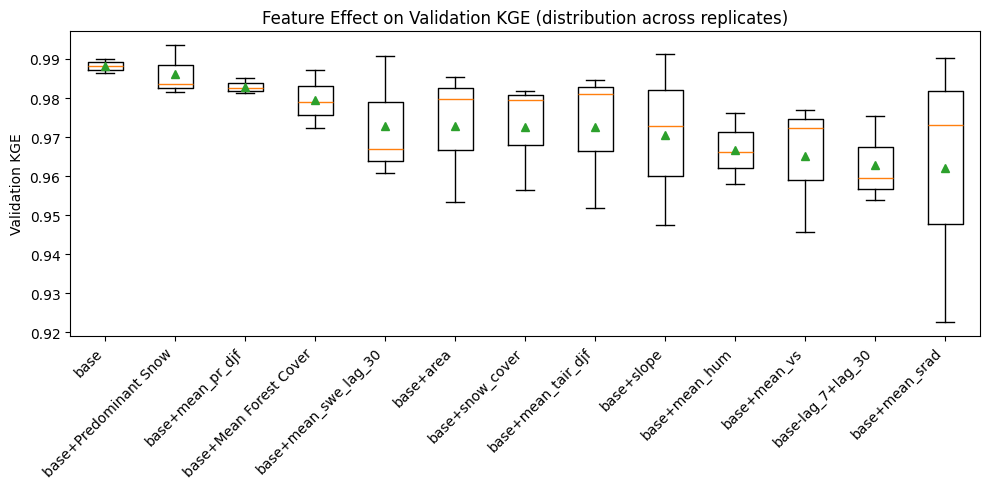

In [72]:
plt.figure(figsize=(10,5))

# Order features by mean KGE (so plot is ranked)
order = (
    df.groupby("added_feature")["val_kge"]
      .mean()
      .sort_values(ascending=False)
      .index
)

data = [df[df["added_feature"] == f]["val_kge"].values for f in order]

plt.boxplot(data, labels=order, showmeans=True)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation KGE")
plt.title("Feature Effect on Validation KGE (distribution across replicates)")
plt.tight_layout()
plt.show()

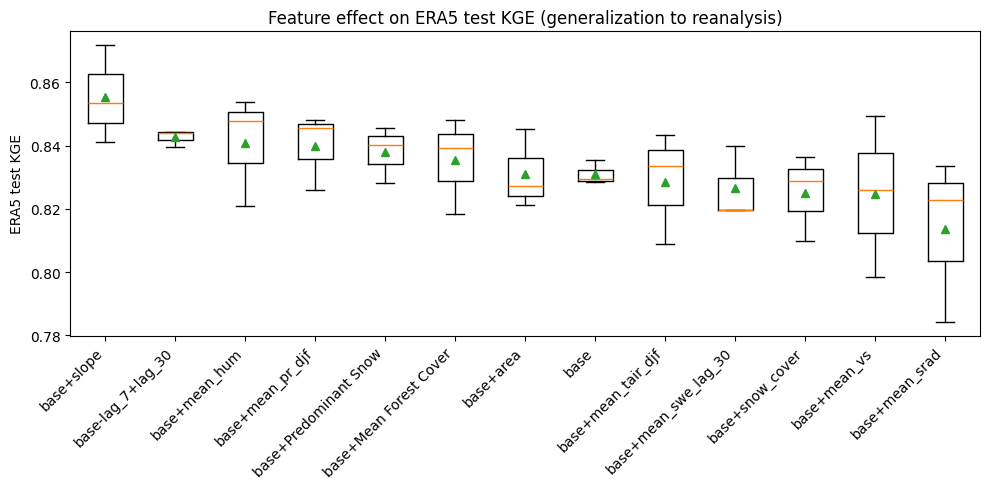

In [73]:
# Box plot: Test KGE on ERA5 data (which models generalize to ERA5)
plt.figure(figsize=(10, 5))
order_era5 = (
    df.groupby("added_feature")["era5_test_kge"]
    .mean()
    .sort_values(ascending=False)
    .index
)
data_era5 = [df[df["added_feature"] == f]["era5_test_kge"].values for f in order_era5]
plt.boxplot(data_era5, tick_labels=order_era5, showmeans=True)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ERA5 test KGE")
plt.title("Feature effect on ERA5 test KGE (generalization to reanalysis)")
plt.tight_layout()
plt.show()

# Load MLflow results

In [57]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

exp = client.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise ValueError(f"Experiment not found: {EXPERIMENT_NAME}")

experiment_id = exp.experiment_id

runs = client.search_runs(
    experiment_ids=[experiment_id],
    order_by=["attributes.start_time DESC"],
    max_results=1000,
)

print("Num runs:", len(runs))
print("Example run_id:", runs[0].info.run_id)

Num runs: 39
Example run_id: 19b0a3915f224bd2b80a9099b118f2bf


In [62]:
results = []

for r in runs:
    run_id = r.info.run_id
    run_name = r.data.tags.get("mlflow.runName", "")
    m = r.data.metrics

    # params saved via mlflow.log_params / log_param
    p = r.data.params

    # tags (useful for run name, etc.)
    t = r.data.tags

    results.append({
        "run_name": run_name,
        # --- metrics (adjust keys to your names) ---
        "val_mse": m.get("best_val_mse"),
        "val_kge": m.get("best_val_kge"),
        "ua_test_mse": m.get("ua_test_mse"),
        "ua_test_kge": m.get("ua_test_kge"),
        "era5_test_mse": m.get("era5_test_mse"),
        "era5_test_kge": m.get("era5_test_kge"),
    })

df = pd.DataFrame(results)
df["added_feature"] = df["run_name"].str.replace(r"_rep\d+$", "", regex=True)
df["replicate"] = df["run_name"].str.extract(r"_rep(\d+)$").astype("Int64")  # nullable int
df = df.drop(columns=["run_name"])
df.to_csv(f"{EXPERIMENT_NAME}_results.csv", index=False)
df

,val_mse,val_kge,ua_test_mse,ua_test_kge,era5_test_mse,era5_test_kge,added_feature,replicate
0,0.001306,0.953764,0.001630,0.964648,0.014117,0.843962,base-lag_7+lag_30,3
1,0.001255,0.975448,0.001650,0.978335,0.013922,0.839531,base-lag_7+lag_30,2
2,0.001280,0.959558,0.001648,0.971534,0.013839,0.844450,base-lag_7+lag_30,1
3,0.000533,0.985435,0.000632,0.985365,0.014359,0.827087,base+area,3
4,0.000585,0.979713,0.000699,0.984649,0.013979,0.845087,base+area,2
5,0.000571,0.953413,0.000684,0.959891,0.014239,0.821195,base+area,1
6,0.000644,0.951827,0.000767,0.959747,0.014221,0.808989,base+mean_tair_djf,3
7,0.000422,0.984518,0.000481,0.987785,0.014123,0.843312,base+mean_tair_djf,2
8,0.000458,0.981143,0.000527,0.982611,0.014108,0.833609,base+mean_tair_djf,1
9,0.000447,0.985095,0.000527,0.985386,0.014426,0.845663,base+mean_pr_djf,3
